In [1]:
# --- Setup: Logging and Display Configuration ---
# Configure logging to see training progress and plotly to render as PNG for VS Code compatibility
import logging
import pandas as pd
import plotly.io as pio

pd.options.plotting.backend = "plotly"
pio.renderers.default = "png"  # Use PNG for VS Code notebook compatibility

logging.basicConfig(level=logging.INFO, format="[%(asctime)s][%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)
logging.getLogger("choreographer").setLevel(logging.ERROR)
logging.getLogger("kaleido").setLevel(logging.ERROR)
logging.getLogger("choreographer").disabled = True
logging.getLogger("kaleido").disabled = True

In [2]:
# Download dataset from HuggingFace Hub
# The dataset is stored as parquet files for efficient loading
from huggingface_hub import hf_hub_download # pyright: ignore[reportUnknownVariableType]
from openstef_core.base_model import Path

repo_id = "OpenSTEF/liander2024-energy-forecasting-benchmark"  # Public benchmark dataset
local_dir = Path("./liander_dataset")
target = "mv_feeder/OS Gorredijk"  # Specific installation to focus on

# Download required files: load measurements, weather, prices, and profiles
files_to_download = [
    f"load_measurements/{target}.parquet",  # Energy consumption data
    f"weather_forecasts_versioned/{target}.parquet",  # Weather features
    "EPEX.parquet",  # Electricity prices (optional feature)
    "profiles.parquet"  # Standard load profiles (optional feature)
]

for filename in files_to_download:
    print(f"Downloading {filename}...")
    hf_hub_download(repo_id=repo_id, filename=filename, repo_type="dataset",
                    local_dir=local_dir, local_dir_use_symlinks=False) # pyright: ignore[reportCallIssue]
    print(f"✓ {filename} downloaded")

print("\n✅ All files downloaded successfully!")

/Users/fleur.petit/projects/openstef/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



/Users/fleur.petit/projects/openstef/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning:

The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.

[2026-03-26 11:11:52,083][INFO] HTTP Request: HEAD https://huggingface.co/datasets/OpenSTEF/liander2024-energy-forecasting-benchmark/resolve/main/load_measurements/mv_feeder/OS%20Gorredijk.parquet "HTTP/1.1 302 Found"
[2026-03-26 11:11:52,244][INFO] HTTP Request: HEAD https://huggingface.co/datasets/OpenSTEF/liander2024-energy-forecasting-benchmark/resolve/main/weather_forecasts_versioned/mv_feeder/OS%20Gorredijk.parquet "HTTP/1.1 302 Found"


✓ load_measurements/mv_feeder/OS Gorredijk.parquet downloaded
✓ weather_forecasts_versioned/mv_feeder/OS Gorredijk.parquet downloaded


[2026-03-26 11:11:52,424][INFO] HTTP Request: HEAD https://huggingface.co/datasets/OpenSTEF/liander2024-energy-forecasting-benchmark/resolve/main/EPEX.parquet "HTTP/1.1 302 Found"
[2026-03-26 11:11:52,425][WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
[2026-03-26 11:11:52,607][INFO] HTTP Request: HEAD https://huggingface.co/datasets/OpenSTEF/liander2024-energy-forecasting-benchmark/resolve/main/profiles.parquet "HTTP/1.1 302 Found"


✓ EPEX.parquet downloaded
✓ profiles.parquet downloaded

✅ All files downloaded successfully!


In [3]:
# Load datasets using OpenSTEF's VersionedTimeSeriesDataset
# This class handles versioned data where each value has an "available_at" timestamp
from openstef_core.datasets import VersionedTimeSeriesDataset

# Load each data source from parquet files
load_dataset = VersionedTimeSeriesDataset.read_parquet(
    local_dir / f"load_measurements/{target}.parquet"
)
weather_dataset = VersionedTimeSeriesDataset.read_parquet(
    local_dir / f"weather_forecasts_versioned/{target}.parquet"
)
epex_dataset = VersionedTimeSeriesDataset.read_parquet(local_dir / "EPEX.parquet")
profiles_dataset = VersionedTimeSeriesDataset.read_parquet(local_dir / "profiles.parquet")

# Combine all datasets using left join (keep all load timestamps, match features where available)
# select_version() materializes the lazy dataset into a concrete TimeSeriesDataset
dataset = VersionedTimeSeriesDataset.concat(
    [load_dataset, weather_dataset, epex_dataset, profiles_dataset], 
    mode="left"  # Left join keeps all timestamps from the first dataset
).select_version()

# Preview the combined dataset
print(f"Dataset shape: {dataset.data.shape}")
print(f"Date range: {dataset.data.index.min()} to {dataset.data.index.max()}")
dataset.data.head()

[2026-03-26 11:11:54,019][WARNING] Parquet file does not contain 'sample_interval' attribute. Using default value of 15 minutes.
[2026-03-26 11:11:54,040][WARNING] Parquet file does not contain 'sample_interval' attribute. Using default value of 15 minutes.
[2026-03-26 11:11:54,065][WARNING] Parquet file does not contain 'sample_interval' attribute. Using default value of 15 minutes.
[2026-03-26 11:11:54,075][WARNING] Parquet file does not contain 'sample_interval' attribute. Using default value of 15 minutes.


Dataset shape: (35136, 28)
Date range: 2024-01-01 00:00:00+00:00 to 2024-12-31 23:45:00+00:00


,load,temperature_2m,relative_humidity_2m,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_80m,wind_direction_10m,shortwave_radiation,direct_radiation,...,E1C_AMI_A,E2A_AZI_A,E2A_AMI_A,E2B_AZI_A,E2B_AMI_A,E3A_A,E3B_A,E3C_A,E3D_A,E4A_A
timestamp,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,423333.333333,7.243500,85.025322,994.236450,100.0,28.185953,43.832863,204.928452,0.0,0.0,...,0.000064,0.000024,0.000034,0.000053,0.000064,0.000058,0.000058,0.000058,0.000058,0.000079
2024-01-01 00:15:00+00:00,436666.666667,7.281000,84.808533,994.186523,100.0,28.753380,44.976219,206.931015,0.0,0.0,...,0.000061,0.000024,0.000034,0.000052,0.000063,0.000058,0.000058,0.000058,0.000058,0.000079
2024-01-01 00:30:00+00:00,410000.000000,7.318501,84.591743,994.136597,100.0,29.320807,46.119572,208.933563,0.0,0.0,...,0.000060,0.000023,0.000033,0.000051,0.000063,0.000058,0.000058,0.000058,0.000058,0.000079
2024-01-01 00:45:00+00:00,403333.333333,7.356000,84.374954,994.086731,100.0,29.888233,47.262924,210.936127,0.0,0.0,...,0.000057,0.000023,0.000032,0.000051,0.000061,0.000059,0.000059,0.000059,0.000059,0.000079
2024-01-01 01:00:00+00:00,420000.000000,7.393500,84.158165,994.036804,100.0,30.455660,48.406281,212.938690,0.0,0.0,...,0.000055,0.000024,0.000032,0.000052,0.000060,0.000057,0.000057,0.000057,0.000057,0.000079


In [4]:
# Define training and forecast time periods
from datetime import datetime, timedelta

# Training period: 90 days of historical data
train_start = datetime.fromisoformat("2024-03-01T00:00:00Z")
train_end = train_start + timedelta(days=90)

# Forecast period: 14 days after training (this is where we'll predict)
forecast_start = train_end
forecast_end = forecast_start + timedelta(days=14)

# Split the dataset using time-based filtering
train_dataset = dataset.filter_by_range(start=train_start, end=train_end)
forecast_dataset = dataset.filter_by_range(start=forecast_start, end=forecast_end)

print(f"📈 Training period: {train_start.date()} to {train_end.date()} ({len(train_dataset.data)} samples)")
print(f"🔮 Forecast period: {forecast_start.date()} to {forecast_end.date()} ({len(forecast_dataset.data)} samples)")

📈 Training period: 2024-03-01 to 2024-05-30 (8640 samples)
🔮 Forecast period: 2024-05-30 to 2024-06-13 (1344 samples)


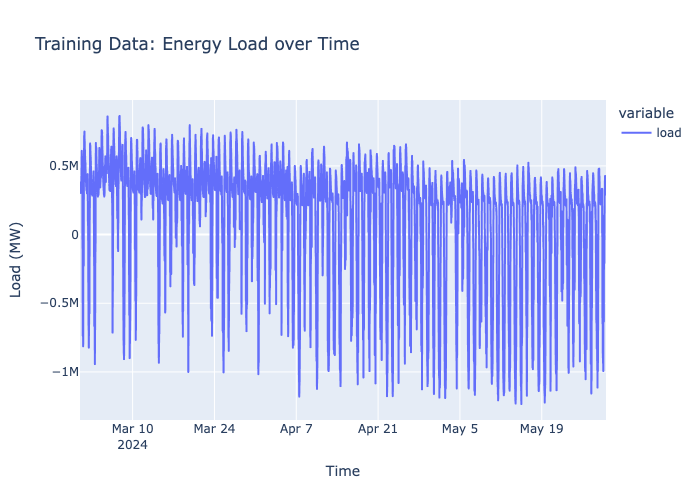

In [5]:
# Visualize the training data
# The plot shows the 'load' column (energy consumption in MW) over time
fig = train_dataset.data[["load"]].plot(title="Training Data: Energy Load over Time")
fig.update_layout(yaxis_title="Load (MW)", xaxis_title="Time")
fig.show()

## Define a base config with inline search space



In [6]:
from openstef_core.types import LeadTime, Q
from openstef_models.models.forecasting.xgboost_forecaster import XGBoostHyperParams
from openstef_models.presets import ForecastingWorkflowConfig, TuningResult, fit_with_tuning
from openstef_models.presets.forecasting_workflow import create_forecasting_workflow
from openstef_models.utils.tuning import CategoricalRange, FloatRange, IntRange

config = ForecastingWorkflowConfig(
    model_id="xgboost_optuna_demo",
    model="xgboost",

    horizons=[LeadTime.from_string("PT36H")],
    quantiles=[Q(0.5), Q(0.1), Q(0.9)],

    target_column="load",
    temperature_column="temperature_2m",
    relative_humidity_column="relative_humidity_2m",
    wind_speed_column="wind_speed_10m",
    radiation_column="shortwave_radiation",
    pressure_column="surface_pressure",

    # Pass TuningRange objects directly as field values — tune=True marks them for Optuna.
    # None values for low/high fall back to the class-level defaults in XGBoostHyperParams.
    xgboost_hyperparams=XGBoostHyperParams(
        n_estimators=200,
        learning_rate=FloatRange(None, None, log=True, tune=True),   # class default: [0.01, 0.5]
        max_depth=IntRange(5, 15, tune=True),
        min_child_weight=FloatRange(None, None, tune=True),          # class default: [1.0, 10.0]
        reg_alpha=FloatRange(None, None, log=True, tune=True),       # class default: [1e-8, 10.0]
        reg_lambda=FloatRange(None, None, log=True, tune=True),      # class default: [1e-8, 10.0]
    ),
    optuna_n_trials=20,
    optuna_seed=42,

    mlflow_storage=None,  # Disable MLflow during tuning
    verbosity=0,
)


/Users/fleur.petit/projects/openstef/.venv/lib/python3.12/site-packages/mlflow/__init__.py:41: UserWarning:

Versions of mlflow (3.9.0) and child packages mlflow-skinny (3.6.0) are different. This may lead to unexpected behavior. Please install the same version of all MLflow packages.



## Inspect the resolved search space


In [7]:
from openstef_models.utils.tuning import FloatRange, IntRange, CategoricalRange, get_search_space

# Merge custom annotated hyperparams with class-level annotated defaults (filling in any None bounds).
resolved_space = get_search_space(config.xgboost_hyperparams)

print("Resolved search space:")
for name, param in resolved_space.items():
    if isinstance(param, (FloatRange, IntRange)):
        scale = "  [log]" if param.log else ""
        print(f"  {name:25s}: {type(param).__name__}  [{param.low} — {param.high}]{scale}")
    else:
        print(f"  {name:25s}: CategoricalRange  {param.choices}")


Resolved search space:
  learning_rate            : FloatRange  [0.01 — 0.5]  [log]
  max_depth                : IntRange  [5 — 15]
  min_child_weight         : FloatRange  [1.0 — 10.0]
  reg_alpha                : FloatRange  [1e-08 — 10.0]  [log]
  reg_lambda               : FloatRange  [1e-08 — 10.0]  [log]


## Run the Optuna study with `fit_with_tuning`

In [8]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Suppress per-trial logs

tuning_result = fit_with_tuning(config, train_dataset, create_forecasting_workflow)

print(f"Study complete: {len(tuning_result.study.trials)} trials")
print(f"Best R²: {tuning_result.study.best_value:.4f}")
print(f"Best hyperparameters:")
for k, v in tuning_result.study.best_params.items():
    print(f"  {k:25s}: {v}")


  0%|          | 0/20 [00:00<?, ?it/s]

Best trial: 12. Best value: 0.8388: 100%|██████████| 20/20 [02:16<00:00,  6.83s/it]


Study complete: 20 trials
Best R²: 0.8388
Best hyperparameters:
  learning_rate            : 0.1661524390633895
  max_depth                : 12
  min_child_weight         : 6.81957188819057
  reg_alpha                : 0.04112476622444426
  reg_lambda               : 0.0022086692193693247


In [9]:
# The best config is already applied inside fit_with_tuning.
# Here we inspect which hyperparameters were tuned vs kept at their default.
print("Final XGBoost hyperparameters (tuned values marked):")
final_hp = tuning_result.workflow.model.forecaster.hyperparams
baseline_hp = config.xgboost_hyperparams
best_params = tuning_result.study.best_params

for field in type(final_hp).model_fields:
    value = getattr(final_hp, field)
    baseline = getattr(baseline_hp, field)
    marker = " <- tuned" if field in best_params else ""
    print(f"  {field:25s}: {value}{marker}")


Final XGBoost hyperparameters (tuned values marked):
  n_estimators             : 200
  learning_rate            : 0.1661524390633895 <- tuned
  max_depth                : 12 <- tuned
  min_child_weight         : 6.81957188819057 <- tuned
  gamma                    : 0
  objective                : pinball_loss
  evaluation_metric        : mean_pinball_loss
  reg_alpha                : 0.04112476622444426 <- tuned
  reg_lambda               : 0.0022086692193693247 <- tuned
  max_delta_step           : 0
  max_leaves               : 0
  grow_policy              : depthwise
  max_bin                  : 256
  num_parallel_trees       : 1
  subsample                : 1.0
  colsample_bytree         : 1.0
  colsample_bylevel        : 1.0
  colsample_bynode         : 1.0
  tree_method              : auto
  random_state             : 42
  early_stopping_rounds    : None
  use_target_scaling       : True


## Full-set training metrics

`fit_with_tuning` trains the final model on the full training set with the best
hyperparameters.  The fit result is available as `tuning_result.fit_result`.


In [10]:
print("Final model already trained by fit_with_tuning!")
print("Full-set metrics (tuned model):")
print(tuning_result.fit_result.metrics_full.to_dataframe())


Final model already trained by fit_with_tuning!
Full-set metrics (tuned model):
   quantile        R2  observed_probability
0       0.5  0.978403              0.503819
1       0.1  0.968634              0.263426
2       0.9  0.955630              0.743750


## Inspect the study and forecast

1. How did $R^2$ improved over trials?
2. Which parameters had the most impact?
3. Final tuned model predictions on the held-out forecast window.


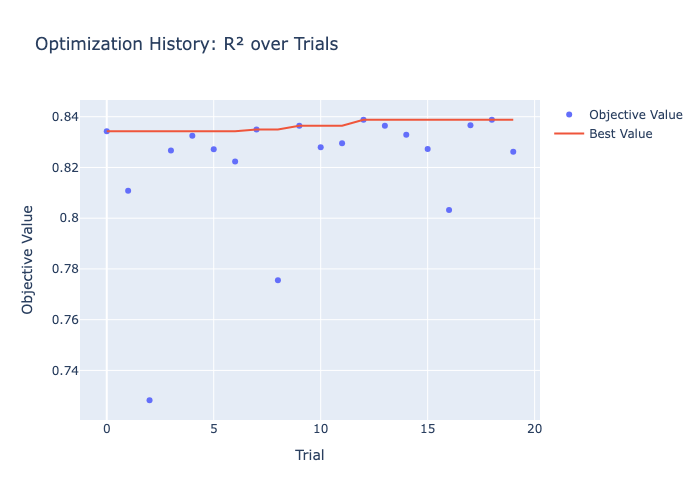

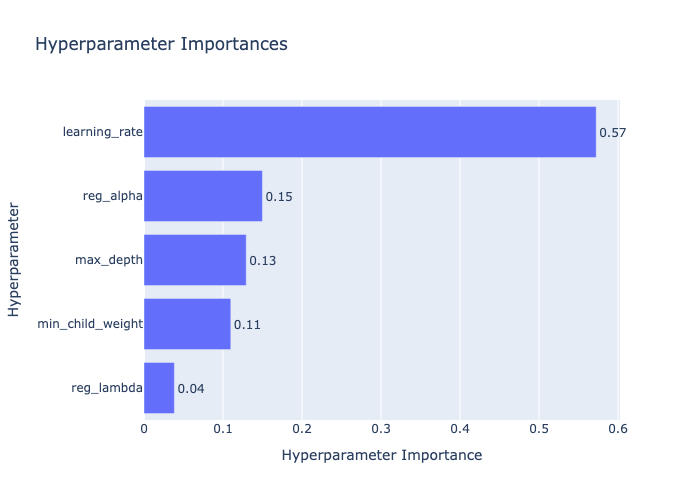

In [11]:
from optuna.visualization import plot_optimization_history, plot_param_importances

study = tuning_result.study

# How the best score evolved over trials
fig = plot_optimization_history(study)
fig.update_layout(title="Optimization History: R² over Trials")
fig.show()

# Which hyperparameters mattered most (requires ≥ ~20 trials for reliable ranking)
fig2 = plot_param_importances(study)
fig2.update_layout(title="Hyperparameter Importances")
fig2.show()


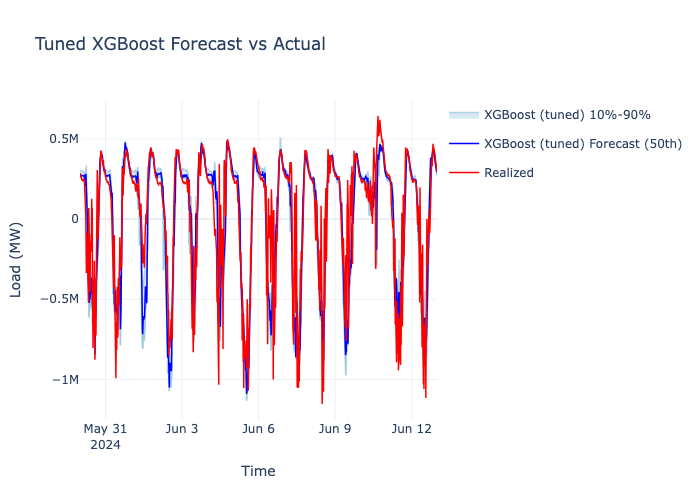

In [12]:
from openstef_beam.analysis.plots import ForecastTimeSeriesPlotter

forecast = tuning_result.workflow.predict(forecast_dataset)

fig = (
    ForecastTimeSeriesPlotter()
    .add_measurements(measurements=forecast_dataset.data["load"])
    .add_model(
        model_name="XGBoost (tuned)",
        forecast=forecast.median_series,
        quantiles=forecast.quantiles_data,
    )
    .plot()
)
fig.update_layout(
    title="Tuned XGBoost Forecast vs Actual",
    yaxis_title="Load (MW)",
    xaxis_title="Time",
    height=500,
)
fig.show()
